# **Quantum Teleportation**
Quantum teleportation is a technique or protocol in quantum physics in which a sender transfers quantum information to a receiver at a different location using the concept of *entanglement*.

This process doesn't involve transporting matter, instead it relies on the principle of quantum entanglement where two particles become linked regardless of distance.

The protocol typically utilizes one entangled pair of qubits (e-bit) and two classical bits. Through a series of precise measurements and classical communication, the quantum state of one qubit can be transferred and recreated at another location, which effectively teleports the quantum information.

### **1. Installing Qiskit Packages**
This section installs the required Qiskit packages to proceed with the project.

In [ ]:
!pip install qiskit  qiskit-ibm-runtime  qiskit-aer
!pip install pylatexenc

#### **1.1. Checking Qiskit Versions**
Now, I will check the versions of the installed Qiskit packages to ensure I am using the required versions for this project.

Usually, the following versions are required to implement the quantum teleportation protocol:

* `qiskit` v2.1.0 or newer
* `qiskit-ibm-runtime` v0.40.1 or newer
* `qiskit-aer` v0.17.0 or newer

In [ ]:
from qiskit import __version__
print(__version__)

from qiskit_ibm_runtime import __version__
print(__version__)

from qiskit_aer import __version__
print(__version__)

2.5.2
0.49.0
0.17.2


#### **1.2. Importing Necessary Libraries**
This section imports the necessary classes and functions from the Qiskit modules to implement the quantum teleportation protocol.

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
import pylatexenc

### **2. Teleportation Setup and Scenario**

---


Consider Alice and Bob are two hypothetical entities who are initially in the same location and can work together on the same qubits.
Note that these two entities are just taken as "abstractions", they're "not necessarily humans".

Suppose they then move apart at two different distant locations, bringing their respective qubits with them.

Now Alice has a qubit 'A', Bob has a qubit 'B', and they share one entangled qubit (e-bit) such that (A,B) is in state $|\phi^+\rangle$ (Bell State):

 $$|A,B\rangle = |\phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) $$

Also Alice has a qubit 'Q' which she wishes to transmit to Bob. Alice isn't able to physically send Q to Bob, she is only able to send classical information. But:

> "It is not possible to transmit quantum information using classical information alone."

 Because according to "Non-Cloning Theorem", it isn't possible as no measurement can fully determine an unknown quantum state.

On contrary, I assume that it's possible to transmit quantum information using classical information with some precision. But it's not quantum communication, it is just representing a quantum state as a vector.

I also assume that:
 * The state of 'Q' is unknown to both Alice and Bob.
 * Correlations (including entanglement) between Q and other systems must be preserved by the transmission.
 * The non-cloning theorem implies that if Bob receives the transmission, Alice must no longer have the qubit in its original state.

 #### **2.1. Circuit and its Operation**

* Alice performs CNOT operation on qubit 'Q' where Q = Control qubit and A (Alice's state) = Target qubit.
* Alice then performs a Hadamard operation on qubit 'Q'.
* Afterwards, Alice measures qubit 'A' and qubit 'Q' with respect to standard basis measurements, obtaining binary outcomes "a" and "b" (classical states) respectively.
* Alice then sends 'a' and 'b' to Bob using two "classical bits"
* After receiving 'a' and 'b', Bob performs these two steps:
  
  * If a = 1, then Bob applies an X-operation to the qubit 'B' (Bob's own qubit).
  * If b = 1, then Bob applies Z-operation to the qubit B.

### **3. Implementing Teleportation Protocols**
For Implementing quantum teleportation, I will start by creating a quantum circuit with three qubits 'A', 'B', and 'Q'.

Then I will entangle the two qubits of Alice('A') and Bob('B'). I will take these qubits to be "qubit 1" and "qubit 2". I will reserve "qubit 0" (qubit of Q) as the secret or unknown state.

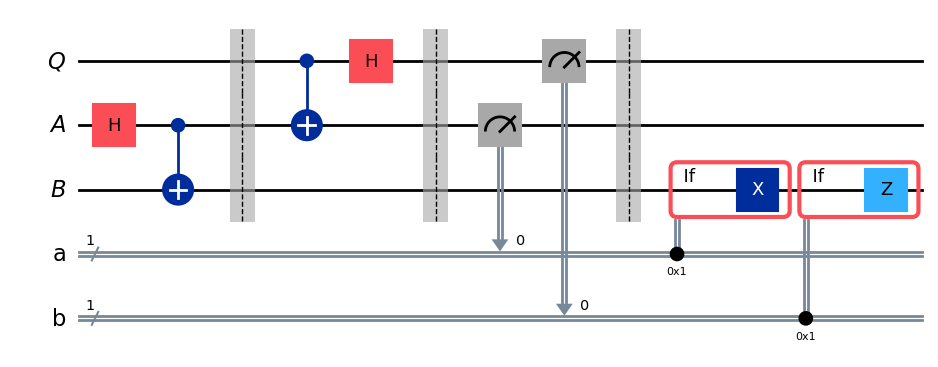

In [ ]:
unknown = QuantumRegister(1, "Q")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

# Creating quantum circuit using above variables.
quantum_circuit = QuantumCircuit(unknown, Alice, Bob, a, b)

# I'm applying Hadamard gate to Alice and then a CNOT gate on both Alice and Bob
# Note that the second argument in CNOT gate is the target quibit

quantum_circuit.h(Alice)       # I created an entangle state of Alice and Bob(e-bit)
quantum_circuit.cx(Alice, Bob)
quantum_circuit.barrier()      # Note that inserting barrier do nothing to logic. It just creates
                               # visual separation, making circuit diagram more readable

# Alice's Operation
quantum_circuit.cx(unknown, Alice)
quantum_circuit.h(unknown)
quantum_circuit.barrier()

# Alice measures and sends classical bits to Bob
quantum_circuit.measure(Alice, a)
quantum_circuit.measure(unknown, b)
quantum_circuit.barrier()

# Then Bob uses classical bits 'a', 'b' to conditionally apply gates

with quantum_circuit.if_test((a, 1)): # Condition should be a tuple (ClassicalRegister, int)
  quantum_circuit.x(Bob)

with quantum_circuit.if_test((b, 1)): # Condition should be a tuple (ClassicalRegister, int)
  quantum_circuit.z(Bob)

# Making my circuit visible
display(quantum_circuit.draw("mpl"))

The circuit first initializes (A,B) to be in state $|\phi^+\rangle$ (which is not the part of teleportation protocol itself), followed by Alice's operation, then Alice's measurement and finally Bob's Operation. Hence, Alice's state teleported to Bob.

To test that protocol works correctly, I will apply a randomly generated
single-qubit gate to the initialized $|0\rangle$ state of 'Q' to obtain a random quantum state vector to be teleported.

By applying the inverse (similar to conjugate transpose) of that gate to 'B' after the protocol is run, I will be able to verify that the state was teleported by measuring to see that it has returned to the state $|0\rangle$.

In [ ]:
random_gate = UGate(                  # Create a single-quibit unitary qiskit gate that has
    theta = random.random() * 2 *pi,  # three parameters: thehta, phi, lambda. These three
    phi = random.random() * 2 * pi,   # parameters determine which quantum operation the
    lam = random.random() * 2 * pi,   # gate performs. Here we used random parameters.
)

display(array_to_latex(random_gate.to_matrix()))  # create the matrix representation of above used quantum gate.

<IPython.core.display.Latex object>

Now I will create a new testing circuit that first applies our random gate to Q, then runs the teleportation circuit, and finally applies the inverse of our random gate to qubit B and measures.

The outcome should be 0 with certainty.

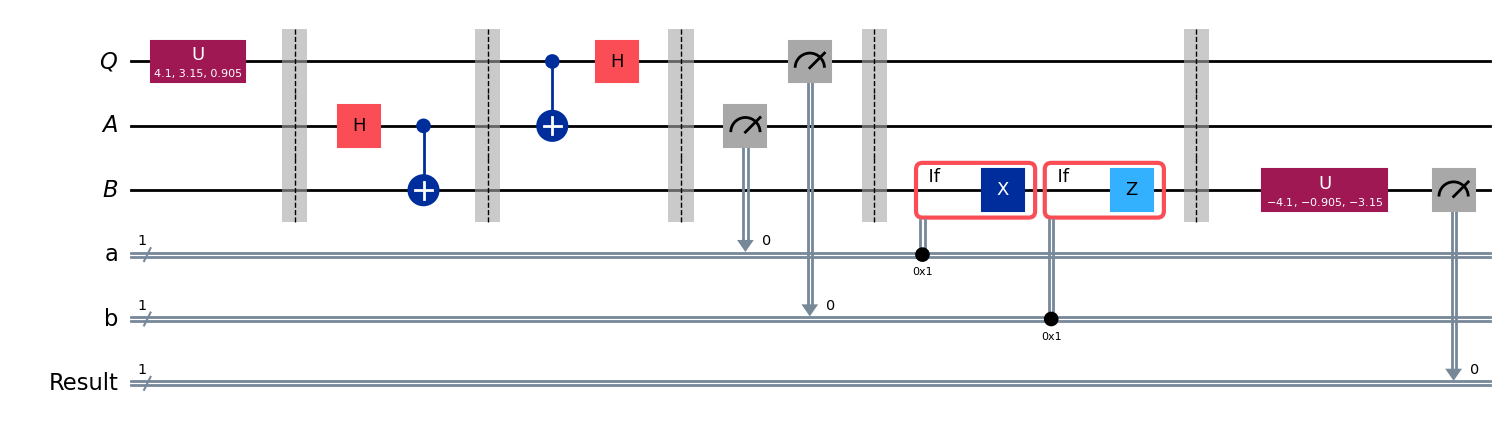

In [ ]:
# create a new testing circuit that include the same bits and quibits
# used in above teleportation protocol.
test = QuantumCircuit(unknown, Alice, Bob, a, b)

# Applying random generated quantum gate on quibit 'Q'
test.append(random_gate, unknown)
test.barrier()

# Joining the entire teleportation circuit created above to newly created testing circuit
test = test.compose(quantum_circuit)
test.barrier()

# Finally, applying the inverse of random unitary gate to B and measure
test.append(random_gate.inverse(), Bob)
result = ClassicalRegister(1,"Result")
test.add_register(result)
test.measure(Bob, result)              # Storing measured qubit "Bob" to the classical register "result"



display(test.draw('mpl'))

As my above testing circuit, in which I measure Bob's qubit, gives $|$$0\rangle$ state, so my teleportation circuit has been verified.

As these measurements are probabilistic, so if there is even small chance of measuring Bob's qubit to be in state $|1\rangle$, then a single measurement could result in $|1\rangle$.

### **4.Running Teleportation Circuit on Aer Simulator**
Now I'm going to run the Aer simulator on above circuit and plot a histogram of the outputs.

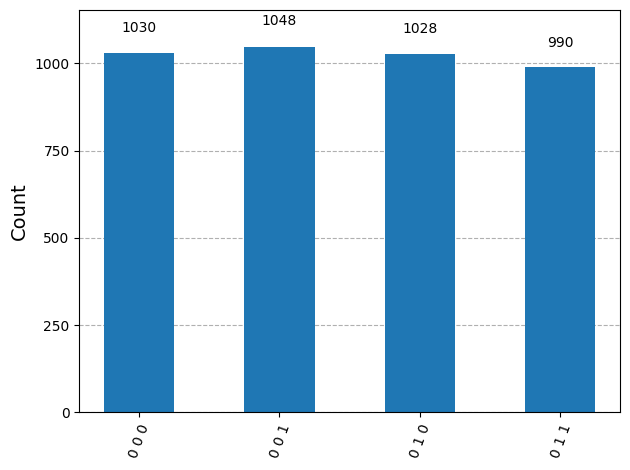

In [ ]:
result = AerSimulator().run(test, shots = 4096).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

The above histogram shows how many times each measurement result occurred for 4096 shots (number of times the entire circuit is executed). It does not mean that four different quantum states being simultaneously present, it is just showing the frequency of measurement outcomes across repeated runs.

The probability of each measurement is:
* P(000) ≈ 1030/4096 ≈ 24.5%
* P(001) ≈ 1048/4096 ≈ 24.9%
* P(010) ≈ 1028/4096 ≈ 23.8%
* P(011) ≈ 990/4096 ≈ 25.7%


As I have three classical bits, so in principle there could be 8 possibilities as follow:

  000, 001, 010, 011, 100, 101, 110, 111

But my histogram has four possibilities. This is because I have designed my circuit in such a way that result / test qubit is always 0 i.e. test/result qubit is deterministic. Therefore, the result beginning with '1' don't occur and my histogram only have the possibilities beginning with '0':
  
  000, 001, 010, 011

The last two bits, after left most '0' bit, are Alice's classical measurement outcomes 'a'and 'b'. They vary randomly and roughly uniformly as expected because they depend only on the random state that was teleported.

To focus only on test/result qubit 0, I filter the statistics by applying
marginalization distribution such that our graph becomes:

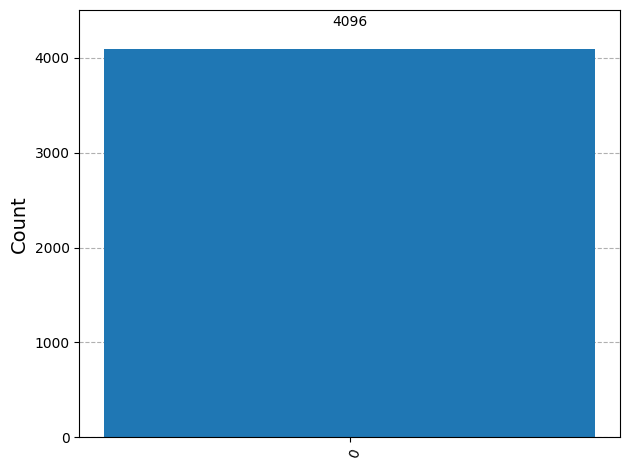

In [ ]:
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

The marginalization operation shows only the result of test / result qubit which is '0' in my case.

Before filtering, I only have:

000 ---> 1030

001 ---> 1048

010 ---> 1028

011 ---> 990

But after marginalizing out Alice's bits, the test qubit measured 0 in all 4096 shots i.e. 100% fidelity on ideal, noiseless simulator / backend. This validates that circuit logic is implemented correctly on aer simulator.


###**5. Running Teleportation Circuit on 156-qubits IBM Fez Quantum computer**
Now I'm going to run my teleportation circuit on real quantum hardware and then I will compare the outputs of both aer simulator(noisless backend) and real quantum hardware(noisy backend)

In [ ]:
# Loading IBM Quantum Compute Service

QiskitRuntimeService.save_account(
    channel = 'ibm_quantum_platform',
    token = '<API is deleted by me after execution>',
    overwrite = True,
    set_as_default = True,
)

service = QiskitRuntimeService(channel = 'ibm_quantum_platform')

# Load Saved Credentials
service = QiskitRuntimeService()

#selecting specific backend for our execution

backend = service.backend('ibm_fez')
print(backend.name)
print(backend.num_qubits)

qiskit_runtime_service.__init__:WARNING:2026-08-25 20:44:19,996: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Muhammad Danyal. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.__init__:WARNING:2026-08-25 20:44:23,201: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Muhammad Danyal. If you need a specific instance set it explicitly either by using a saved account with a saved default i

ibm_fez
156


In [ ]:
#Transpiling
target = backend.target
pass_manager = generate_preset_pass_manager(target = target, optimization_level = 3)
qc_isa = pass_manager.run(test)

A "Sampler" is a primitive designed to sample possible states resulting from quantum circuit.
It collects statistics about which state might be measured and with what probability

In [ ]:
sampler = Sampler(mode = backend)

job = sampler.run([qc_isa], shots=4096)
res = job.result()
counts = res[0].data.Result.get_counts()

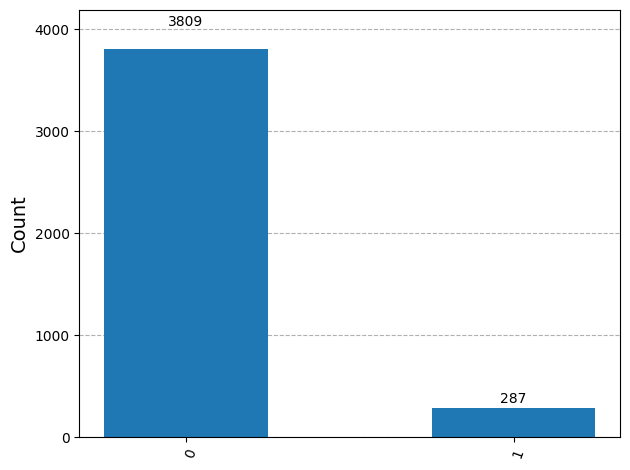

In [ ]:
plot_histogram(counts)

#### Results of 156-qubit real quantum hardware
After running my job on IBM's real 156-qubit "Fez" quantum computer using IBM's cloud services, I have achieved the following results:
*  Out of 4096 shots, 3809 shots measured a "0" bit, indicating "successful teleportation" on real quantum hardware.
* The remaining 287 shots out of 4096 indicate failed teleportation. This failure is due to the fact that real hardware is subject to noise like gate errors, decoherence, etc.  

Overall, I have achieved a success rate of 93%. So teleportation still works most of the time, but not perfectly because real hardware isn't perfect. On the other hand, the Aer simulator is just a mathematical model of a quantum computer with no real-world flaws, which is why teleportation worked 100% of the time.

### **6. Conclusion**
This project successfully demonstrated the quantum teleportation protocol. I accurately implemented the protocol where:
*  I have tested its functionality on an ideal quantum simulator   
* And also observed its performance on a IBM's 156-qubits real quantum computer.

While simulator achieved perfect fidelity, the real hardware showed  93% success rate due to imperfection by quantum noise. This work not only validates the theoretical principles of quantum teleportation but also provides hands-on experience into the realities of quantum computing on existing hardware.

*Fidelity* tells how close an actual quantum state is to the desired / ideal quantum state.
